# Исследование 1. Ассортимент маркетплейса

## Бизнес-задача
Определить, какие товары формируют выручку, где стоит проверить глубину скидки и какие позиции требуют проверки перед выводом из ассортимента. Адресаты — категорийный менеджер и руководитель коммерческого блока.

Результат — конкретные списки SKU с правилами отбора, расчёт возможного изменения выручки и план проверки. Вывод товара или изменение цены не выполняется автоматически: для окончательного решения нужны маржа и остатки.

План: качество данных → структура продаж → ABC → стабильность помесячного спроса → кандидаты на ценовой тест → кандидаты на проверку ассортимента → рекомендации.

## Данные и ограничения
Источник: учебный API `http://final-project.simulative.ru/data`, по одному запросу на день. Период исследования: 01.01–31.12.2023. Сначала сохранены исходные ответы, затем проверены типы, дата, количество, скидка и равенство `total_price = quantity × (price_per_item − discount_per_item)`.

В анализ включены положительные количества с корректными реквизитами и суммой. Нулевые количества и другие ошибки строк помещены в карантин. При смешанных или пропущенных датах весь ответ API запрашивается повторно. Даты не подставляются из URL: такая подстановка могла бы приписать чужие продажи другому дню. Запросы выполняются строго последовательно после выявления дефекта параллельной выдачи API. Пустой ответ означает отсутствие строк в ответе, а не доказанное отсутствие реальных продаж. Исключения могут смещать результаты, особенно сравнения дней и месяцев.

Одна запись — товарная строка покупки. **ID заказа отсутствует**, поэтому не считаются число заказов и средний чек заказа. Валюта не описана поставщиком, суммы обозначены как **денежные единицы**. Нет названий, категорий, себестоимости, остатков, просмотров и рекламных затрат. Нельзя доказать прибыльность SKU, потерянный спрос, окупаемость привлечения или причинный эффект скидок. Данные учебные; рекомендации — проекты проверяемых решений для этого набора, а не утверждения о реальной компании.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
ROOT = Path.cwd()
DATA = ROOT / 'data/research'
OUT = ROOT / 'results'
OUT.mkdir(exist_ok=True)
plt.rcParams.update({'font.family':'DejaVu Sans','figure.dpi':120,
    'axes.spines.top':False,'axes.spines.right':False})
pd.set_option('display.max_columns', 15)
pd.set_option('display.float_format',lambda x:f'{x:,.2f}')
coverage = pd.read_csv(DATA/'coverage.csv')
assert len(coverage)==365
quality = pd.read_csv(DATA/'quality_reasons.csv')
source_rows = coverage.source_rows.sum()
accepted_rows = coverage.accepted_rows.sum()
reject_rate = coverage.rejected_rows.sum()/source_rows
display(pd.DataFrame({'Показатель':['Дней API','Строк источника','Строк в анализе','Доля исключённых','Пустых ответов','Дней без принятых строк'],
    'Значение':[len(coverage),source_rows,accepted_rows,f'{reject_rate:.2%}',
    int((coverage.source_rows==0).sum()),int((coverage.accepted_rows==0).sum())]}))
display(quality)

,Показатель,Значение
0,Дней API,365
1,Строк источника,2040076
2,Строк в анализе,1999609
3,Доля исключённых,1.98%
4,Пустых ответов,0
5,Дней без принятых строк,0


,reason,rows
0,nonpositive or oversized quantity,40399
1,invalid time,34
2,invalid identifier,34


## 1. Продажи и наблюдаемая динамика
Выручка — сумма `total_price` после скидок. Скидка — сумма скидки на единицу, умноженной на количество. Доля скидки считается от общей стоимости до скидок, а не как простое среднее процентов отдельных строк. Сравнение месяцев сопровождается долей отклонённых строк: неполный месяц не следует интерпретировать как падение спроса.

SKU: 49999 Выручка: 1674638193280.0 Количество единиц: 67273106
Взвешенная доля скидки: 0.5003


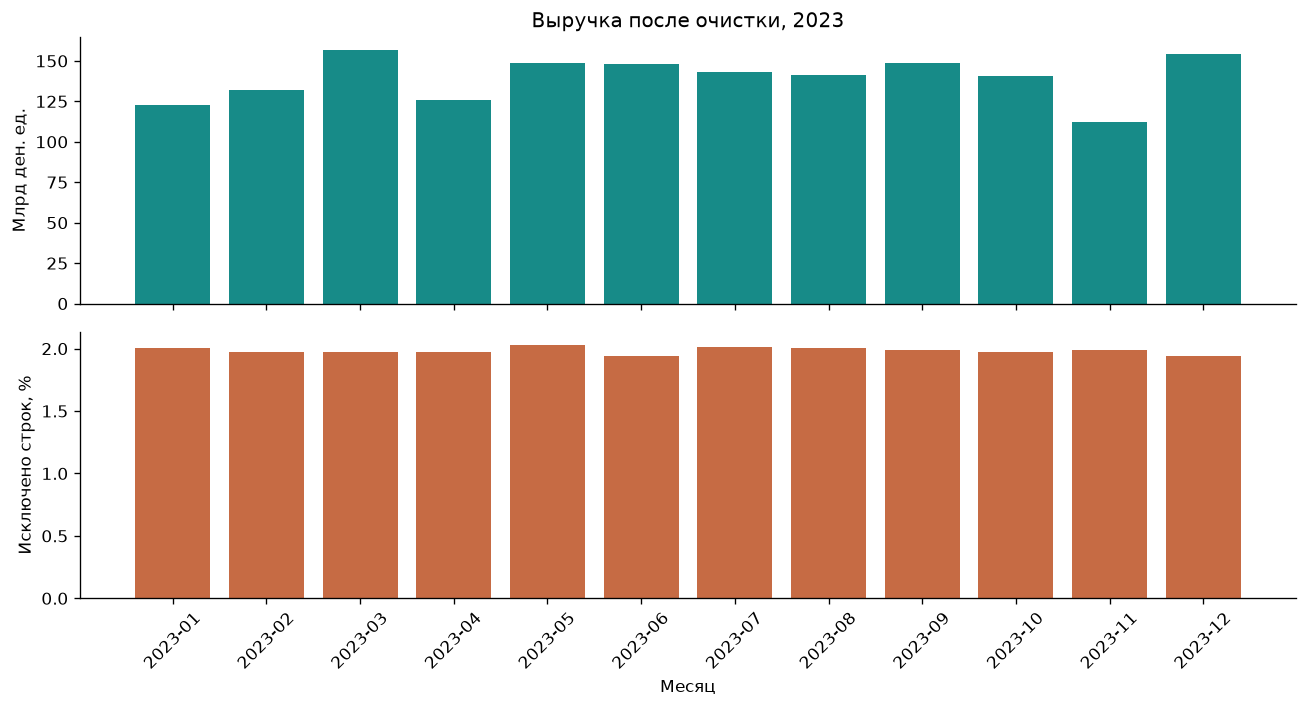

In [2]:
products=pd.read_csv(DATA/'products.csv')
monthly=pd.read_csv(DATA/'monthly.csv',parse_dates=['month'])
products['discount_share']=products.discount_amount/products.gross.replace(0,np.nan)
products['net_unit_price']=products.revenue/products.units
assert np.isclose(products.revenue.sum(),monthly.revenue.sum())
assert int(products.purchase_lines.sum())==int(accepted_rows)
print('SKU:',len(products),'Выручка:',round(products.revenue.sum(),2),'Количество единиц:',int(products.units.sum()))
print('Взвешенная доля скидки:',round(products.discount_amount.sum()/products.gross.sum(),4))
q=coverage.assign(month=pd.to_datetime(coverage.sale_date).dt.to_period('M').astype(str)).groupby('month')[['source_rows','rejected_rows']].sum()
fig,axes=plt.subplots(2,1,figsize=(11,6),sharex=True)
axes[0].bar(monthly.month.dt.strftime('%Y-%m'),monthly.revenue/1e9,color='#178b88')
axes[0].set(ylabel='Млрд ден. ед.',title='Выручка после очистки, 2023')
axes[1].bar(q.index,100*q.rejected_rows/q.source_rows,color='#c66b44')
axes[1].set(ylabel='Исключено строк, %',xlabel='Месяц')
axes[1].tick_params(axis='x',rotation=45)
plt.tight_layout(); plt.show()

## 2. ABC-анализ
Товары сортируются по выручке. Группа A включает позиции до достижения 80% накопленной выручки, B — следующие до 95%, C — остальные. Товар, пересекающий порог, остаётся в предыдущей группе: классификация опирается на накопленную долю **до** текущего товара. Нулевая выручка относится к C. Это сегментация вклада в выручку, а не маржи.

,skus,revenue,units,sku_share,revenue_share
ABC,,,,,
A,26996,"1,339,724,054,018.00",37512502,0.54,0.80
B,11509,"251,187,213,750.00",14878401,0.23,0.15
C,11494,"83,726,925,512.00",14882203,0.23,0.05


,product_id,revenue,units,clients,discount_share,ABC
0,37181,"126,506,926.00",2348,60,0.46,A
1,30239,"122,577,085.00",2121,48,0.41,A
2,22406,"122,007,891.00",2119,51,0.41,A
3,10292,"121,115,031.00",2202,61,0.45,A
4,45018,"118,322,228.00",2235,58,0.45,A
5,24299,"117,852,522.00",2074,59,0.42,A
6,11714,"113,646,456.00",1963,54,0.41,A
7,40657,"113,584,037.00",2108,53,0.46,A
8,696,"112,019,601.00",2425,62,0.46,A
9,182,"110,779,224.00",2413,56,0.51,A


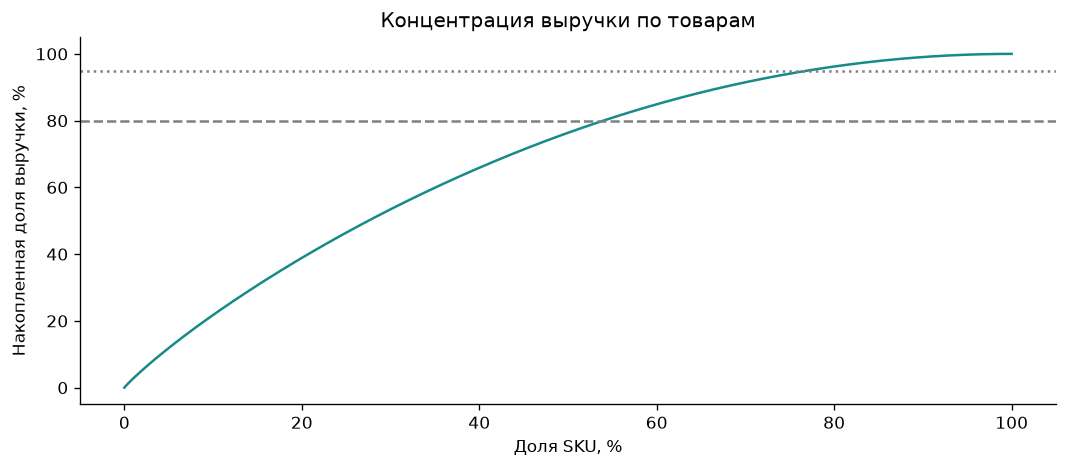

In [3]:
products=products.sort_values(['revenue','product_id'],ascending=[False,True]).reset_index(drop=True)
products['revenue_share']=products.revenue/products.revenue.sum()
before=products.revenue_share.cumsum()-products.revenue_share
products['ABC']=np.select([(before<.8)&(products.revenue>0),(before<.95)&(products.revenue>0)],['A','B'],default='C')
abc=products.groupby('ABC').agg(skus=('product_id','size'),revenue=('revenue','sum'),units=('units','sum'))
abc['sku_share']=abc.skus/len(products)
abc['revenue_share']=abc.revenue/products.revenue.sum()
display(abc)
top=products.head(10)[['product_id','revenue','units','clients','discount_share','ABC']]
display(top)
fig,ax=plt.subplots(figsize=(9,4))
ax.plot(100*(np.arange(len(products))+1)/len(products),100*products.revenue_share.cumsum(),color='#178b88')
ax.axhline(80,ls='--',color='gray'); ax.axhline(95,ls=':',color='gray')
ax.set(xlabel='Доля SKU, %',ylabel='Накопленная доля выручки, %',title='Концентрация выручки по товарам')
plt.tight_layout(); plt.show()
abc.to_csv(OUT/'assortment_abc.csv',encoding='utf-8-sig')

## 3. Стабильность и сопоставимость товаров
Для каждого SKU считаются число месяцев с продажами и коэффициент вариации месячного количества (стандартное отклонение / среднее). Неактивный месяц заполняется нулём только в пределах полного календарного 2023 года. Это ноль **наблюдаемых принятых продаж**, а не подтверждение отсутствия спроса.

Сопоставление минимальной и максимальной цены по одному ID — дополнительная проверка смысла товарного идентификатора. Очень широкий разброс может означать изменение цены, разные варианты товара или особенность генератора. Без справочника выбрать объяснение нельзя.

In [4]:
pm=pd.read_csv(DATA/'product_months.csv',parse_dates=['month'])
pivot=pm.pivot(index='product_id',columns='month',values='units').reindex(columns=pd.date_range('2023-01-01','2023-12-01',freq='MS')).fillna(0)
products=products.join((pivot>0).sum(axis=1).rename('active_months'),on='product_id')
products=products.join((pivot.std(axis=1,ddof=0)/pivot.mean(axis=1)).rename('monthly_cv'),on='product_id')
products['list_price_ratio']=products.max_list_price/products.min_list_price.replace(0,np.nan)
display(products[['active_months','monthly_cv','list_price_ratio']].describe())
wide_price=(products.list_price_ratio>10).sum()
display(Markdown(f'У **{wide_price:,} из {len(products):,} SKU** максимальная заявленная цена более чем в 10 раз выше минимальной. Перед ценовыми решениями необходимо проверить, что один product_id действительно обозначает сопоставимый товар.'))

,active_months,monthly_cv,list_price_ratio
count,"49,999.00","49,999.00","49,999.00"
mean,11.55,0.64,1.00
std,0.66,0.14,0.00
min,7.00,0.17,1.00
25%,11.00,0.54,1.00
50%,12.00,0.63,1.00
75%,12.00,0.73,1.00
max,12.00,1.48,1.00


У **0 из 49,999 SKU** максимальная заявленная цена более чем в 10 раз выше минимальной. Перед ценовыми решениями необходимо проверить, что один product_id действительно обозначает сопоставимый товар.

## 4. Конкретные кандидаты для проверки скидки
Выбираются товары группы A с взвешенной скидкой не менее 50%, продажами минимум в 10 месяцах и минимум 30 покупателями за год. Отбор не доказывает избыточность скидки: он выделяет большой денежный объём, на котором небольшой проверяемый эффект был бы заметен. Порог 30 — фильтр совсем редких позиций, а не достаточный размер выборки для ценового теста.

Сценарий: уменьшить **среднюю взвешенную** скидку на 2 процентных пункта стоимости до скидок. При неизменных количестве и структуре покупок дополнительная выручка равна `0,02 × gross`. Допустимое падение количества до нулевого эффекта на выручку равно `прирост / (исходная выручка + прирост)`. Это арифметический сценарий на годовом объёме, не прогноз и не расчёт прибыли. Практический механизм акции необходимо сверить с реальными правилами скидок.

In [5]:
candidates=products[(products.ABC=='A')&(products.discount_share>=.5)&(products.active_months>=10)&(products.clients>=30)].copy()
candidates['scenario_extra_revenue']=.02*candidates.gross
candidates['break_even_unit_loss']=candidates.scenario_extra_revenue/(candidates.revenue+candidates.scenario_extra_revenue)
candidates=candidates.sort_values('scenario_extra_revenue',ascending=False).head(10)
display(candidates[['product_id','revenue','clients','discount_share','scenario_extra_revenue','break_even_unit_loss']])
candidates.to_csv(OUT/'assortment_discount_pilot.csv',index=False,encoding='utf-8-sig')
audit=products[products.ABC=='C'].sort_values(['revenue','clients']).head(15)
display(audit[['product_id','revenue','units','clients','active_months','monthly_cv']])
audit.to_csv(OUT/'assortment_review_candidates.csv',index=False,encoding='utf-8-sig')

,product_id,revenue,clients,discount_share,scenario_extra_revenue,break_even_unit_loss
13,43727,"109,358,883.00",52,0.52,"4,579,902.54",0.04
9,182,"110,779,224.00",56,0.51,"4,476,887.16",0.04
48,3318,"102,687,603.00",61,0.52,"4,289,792.92",0.04
73,21325,"99,527,247.00",59,0.53,"4,269,813.00",0.04
44,17283,"103,088,520.00",50,0.52,"4,260,774.94",0.04
185,4889,"93,169,135.00",62,0.56,"4,232,024.42",0.04
89,40138,"98,261,634.00",59,0.53,"4,182,488.24",0.04
181,14214,"93,342,864.00",56,0.55,"4,161,417.32",0.04
189,49963,"92,917,602.00",49,0.54,"4,046,331.00",0.04
890,41354,"80,294,794.00",52,0.60,"4,041,483.94",0.05


,product_id,revenue,units,clients,active_months,monthly_cv
49998,5945,654.00,1323,44,12,0.61
49997,38944,"1,453.00",1056,33,11,0.71
49996,25894,"1,792.00",1884,57,12,0.60
49995,22981,"3,960.00",1578,50,11,0.53
49994,35351,"4,154.00",1261,35,12,0.66
49993,38052,"5,448.00",1289,41,12,0.42
49992,47837,"7,392.00",1113,36,11,0.63
49991,34283,"8,897.00",1303,34,10,0.77
49990,33746,"10,832.00",963,29,12,0.62
49989,45824,"11,042.00",1079,35,12,0.65


## 5. Рекомендации категорийным менеджерам

**Первое действие — проверить справочник и качество источника.** Для выбранных SKU получить название, вариант, категорию, закупочную цену, историю прайс-листа и промо. Если ID смешивает разные варианты или даты ненадёжны, сначала исправить контракт данных. Исключённые продажи не считать потерянным спросом.

**Затем провести ценовой пилот на списке `assortment_discount_pilot.csv`.** После проверки идентификаторов выбрать первые 3 SKU из таблицы. Разделить подходящих клиентов случайно на две группы с постоянным закреплением; контроль сохраняет текущую скидку, тест уменьшает её по согласованной схеме. Основная метрика — маржинальный доход на назначенного клиента за фиксированный период. Пока себестоимость не доступна, использовать выручку на назначенного клиента только как предварительный показатель, не как доказательство прибыльности. Контролировать конверсию, возвраты и повторную покупку. Длительность и размер выборки рассчитать по клиентской дисперсии и минимально полезному эффекту до запуска; не завершать тест при первом значимом p-value. Рассчитанный порог потери количества — сценарный ориентир, а не статистическое правило остановки.

**Группу C не удалять автоматически.** Для конкретных 15 SKU из второй таблицы проверить остатки, число дней доступности, маржу и долю совместных покупок с товарами A. Низкая выручка может объясняться отсутствием товара на складе или ролью дополняющей позиции. Вывод обсуждать только при подтверждённой доступности и отрицательном экономическом вкладе. Нулевой остаток требует восстановления поставки, а не вывода позиции.

**Не расширять ассортимент по этим данным вслепую.** Без категорий, поисковых запросов и неуспешных просмотров нельзя назвать обоснованные новые позиции. Следующий сбор данных: запросы без результата, просмотры карточек, остатки, замены и товары в корзинах. Это позволит отличить отсутствующий спрос от неудовлетворённого.

### Итог в числах

In [6]:
lines=[f'В исследовании {len(products):,} продававшихся SKU и {accepted_rows:,} принятых товарных строк; исключено {reject_rate:.2%} исходных строк.',
f'Группа A: {int(abc.loc["A","skus"]):,} SKU ({abc.loc["A","sku_share"]:.1%} ассортимента), {abc.loc["A","revenue_share"]:.1%} выручки.',
f'Для проверки глубины скидки отобрано {len(candidates)} SKU. Суммарный сценарный прирост при прежнем объёме: {candidates.scenario_extra_revenue.sum():,.0f} денежных единиц за год. Этот эффект не гарантирован.',
'Файлы с конкретными product_id и расчётами приложены; решения требуют подтверждения стоимости и идентичности товаров.']
display(Markdown('\n\n'.join(lines)))
products.to_csv(OUT/'assortment_products.csv',index=False,encoding='utf-8-sig')

В исследовании 49,999 продававшихся SKU и 1,999,609 принятых товарных строк; исключено 1.98% исходных строк.

Группа A: 26,996 SKU (54.0% ассортимента), 80.0% выручки.

Для проверки глубины скидки отобрано 10 SKU. Суммарный сценарный прирост при прежнем объёме: 42,540,915 денежных единиц за год. Этот эффект не гарантирован.

Файлы с конкретными product_id и расчётами приложены; решения требуют подтверждения стоимости и идентичности товаров.